In [1]:
EXP_NAME = "finetuning_recon_params_0"

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

search_results = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/search_results.csv')
dataset = pd.read_csv(f'{PROJECT_ROOT}/data/heart_disease_cleaned.csv')

# Analysis

In [4]:
search_results['delta_desc_auc'] = abs(search_results['u_desc_sens_auc_mean'] - 0.5) - abs(search_results['x_desc_sens_auc_mean'] - 0.5)
search_results['desc_to_corr_ratio'] = search_results['desc_a'] / search_results['corr_a']
search_results['desc_to_pred_ratio'] = search_results['desc_a'] / search_results['pred_a']

In [5]:
params = ["corr_a", "desc_a", "desc_to_corr_ratio", "desc_to_pred_ratio", "u_ind_b"]
metrics = ["delta_desc_auc", "te_error", "auprc", "roc_auc",  "fnr", "fpr", "brier_score", "u_u_cca",  "u_desc_recon_loss",  "internal_te_error"]

In [6]:
long_results = search_results[params + metrics].melt(id_vars=metrics, value_vars=params, value_name="param_value", var_name="parameter")

print(long_results.groupby(['parameter'])["param_value"].value_counts().sort_index())
# for param in params:
#   print(search_results[param].value_counts().sort_index())

parameter           param_value
corr_a              1.000000       21
                    1.250000       15
                    1.500000        9
desc_a              1.000000       15
                    1.250000       21
                    1.500000        9
desc_to_corr_ratio  0.800000        6
                    0.833333        6
                    1.000000       18
                    1.200000        3
                    1.250000        9
                    1.500000        3
desc_to_pred_ratio  1.000000       15
                    1.250000       21
                    1.500000        9
u_ind_b             0.500000       24
                    1.000000       15
                    1.500000        6
Name: count, dtype: int64


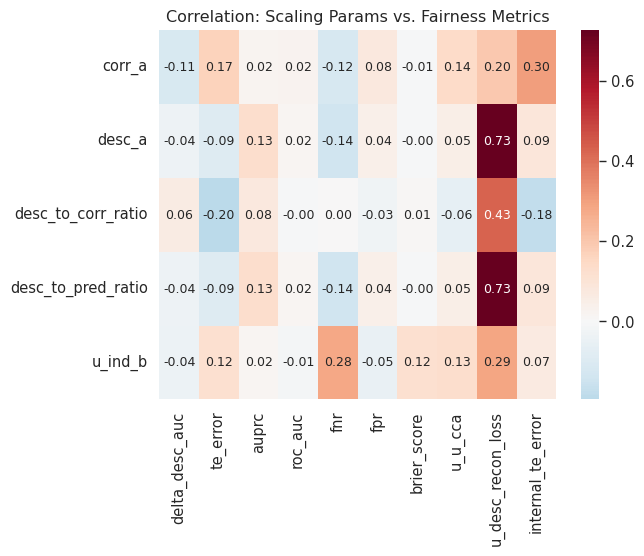

In [7]:
corr_matrix = search_results[params + metrics].corr(method='spearman')
param_metrics_corr = corr_matrix.loc[params, metrics]

sns.heatmap(param_metrics_corr, annot=True, fmt='.2f', annot_kws={"fontsize":9}, cmap='RdBu_r', center=0)
plt.title('Correlation: Scaling Params vs. Fairness Metrics')
plt.show()

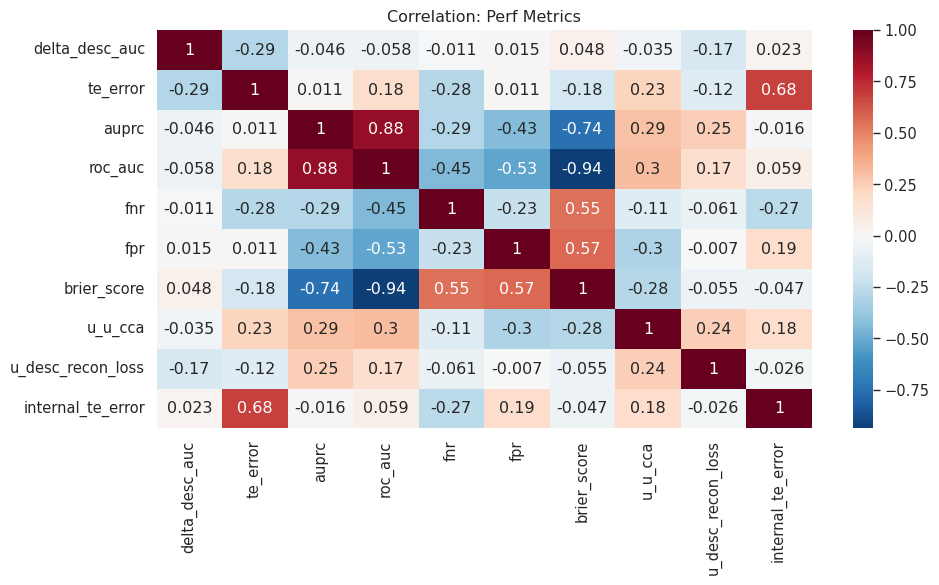

In [8]:
metrics_metrics_corr = corr_matrix.loc[metrics, metrics]

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_metrics_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation: Perf Metrics')
plt.tight_layout()
plt.show()

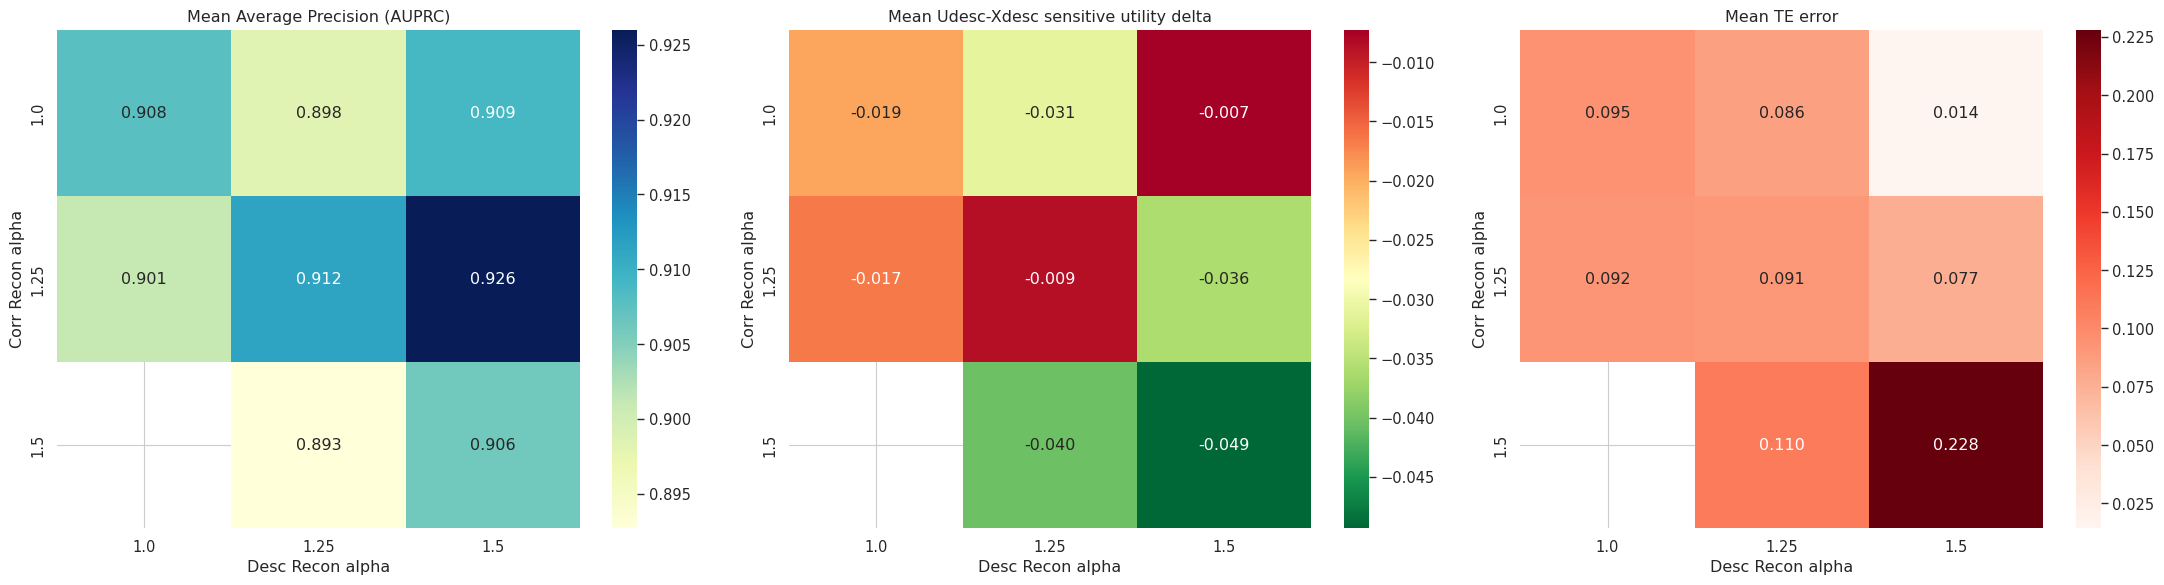

In [9]:
desc_corr_pivot_1 = search_results.pivot_table(columns="desc_a", index="corr_a", values='auprc', aggfunc="mean")
desc_corr_pivot_2 = search_results.pivot_table(columns="desc_a", index="corr_a", values='delta_desc_auc', aggfunc="mean")
desc_corr_pivot_3 = search_results.pivot_table(columns="desc_a", index="corr_a", values='te_error', aggfunc="mean")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(desc_corr_pivot_1, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean Average Precision (AUPRC)")
axes[0].set_xlabel("Desc Recon alpha")
axes[0].set_ylabel("Corr Recon alpha")
sns.heatmap(desc_corr_pivot_2, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1])
axes[1].set_title("Mean Udesc-Xdesc sensitive utility delta")
axes[1].set_xlabel("Desc Recon alpha")
axes[1].set_ylabel("Corr Recon alpha")
sns.heatmap(desc_corr_pivot_3, annot=True, fmt=".3f", cmap="Reds", ax=axes[2])
axes[2].set_title("Mean TE error")
axes[2].set_xlabel("Desc Recon alpha")
axes[2].set_ylabel("Corr Recon alpha")

plt.tight_layout()
plt.show()

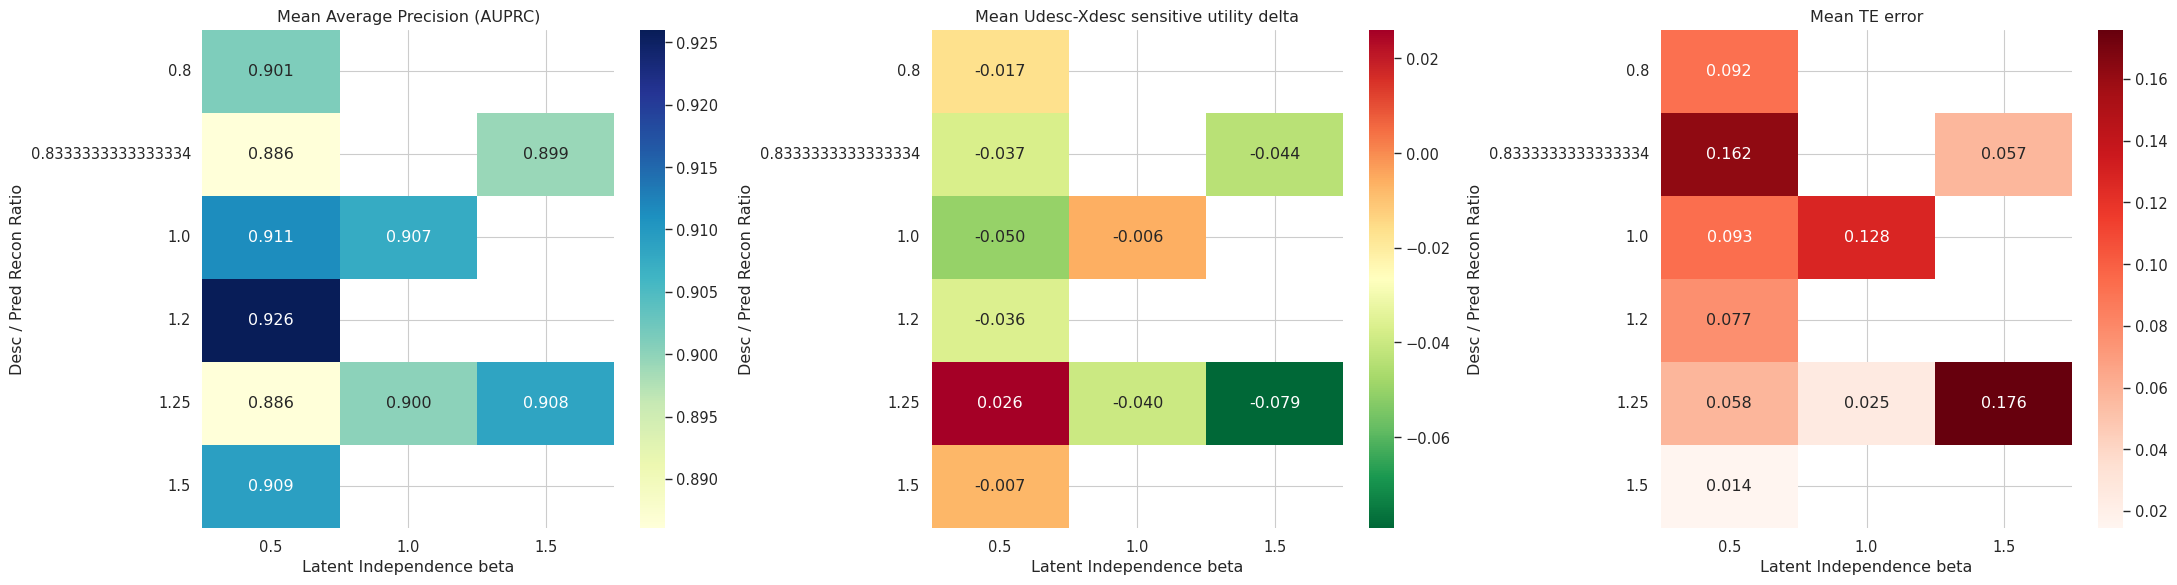

In [10]:
u_ind_recon_pivot_1 = search_results.pivot_table(columns="u_ind_b", index="desc_to_corr_ratio", values='auprc', aggfunc="mean")
u_ind_recon_pivot_2 = search_results.pivot_table(columns="u_ind_b", index="desc_to_corr_ratio", values='delta_desc_auc', aggfunc="mean")
u_ind_recon_pivot_3 = search_results.pivot_table(columns="u_ind_b", index="desc_to_corr_ratio", values='te_error', aggfunc="mean")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(u_ind_recon_pivot_1, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean Average Precision (AUPRC)")
axes[0].set_xlabel("Latent Independence beta")
axes[0].set_ylabel("Desc / Pred Recon Ratio")
sns.heatmap(u_ind_recon_pivot_2, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1])
axes[1].set_title("Mean Udesc-Xdesc sensitive utility delta")
axes[1].set_xlabel("Latent Independence beta")
axes[1].set_ylabel("Desc / Pred Recon Ratio")
sns.heatmap(u_ind_recon_pivot_3, annot=True, fmt=".3f", cmap="Reds", ax=axes[2])
axes[2].set_title("Mean TE error")
axes[2].set_xlabel("Latent Independence beta")
axes[2].set_ylabel("Desc / Pred Recon Ratio")

plt.tight_layout()
plt.show()

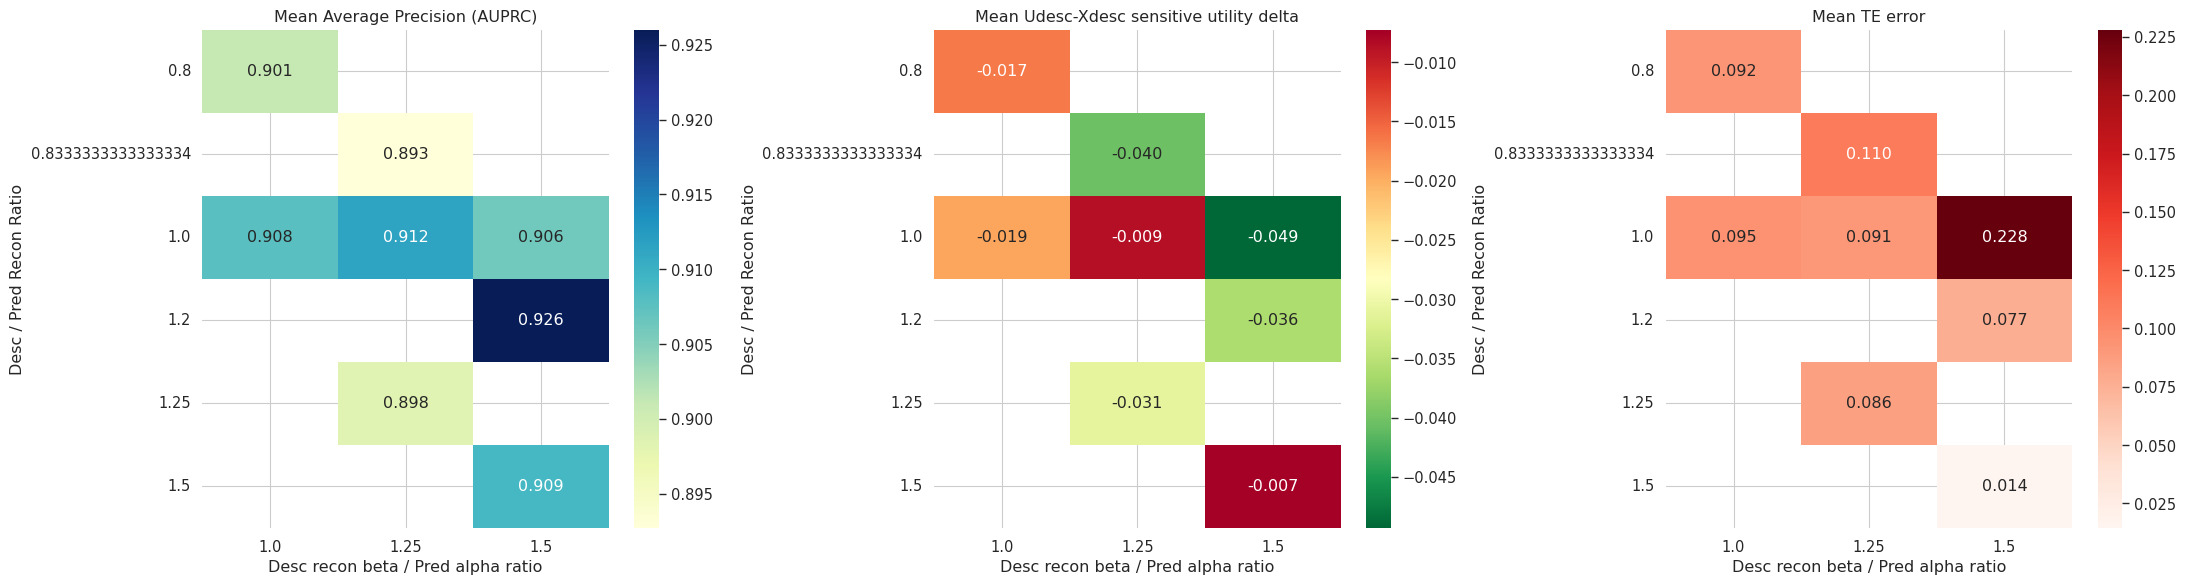

In [11]:
pred_recon_pivot_1 = search_results.pivot_table(columns="desc_to_pred_ratio", index="desc_to_corr_ratio", values='auprc', aggfunc="mean")
pred_recon_pivot_2 = search_results.pivot_table(columns="desc_to_pred_ratio", index="desc_to_corr_ratio", values='delta_desc_auc', aggfunc="mean")
pred_recon_pivot_3 = search_results.pivot_table(columns="desc_to_pred_ratio", index="desc_to_corr_ratio", values='te_error', aggfunc="mean")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(pred_recon_pivot_1, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Mean Average Precision (AUPRC)")
axes[0].set_xlabel("Desc recon beta / Pred alpha ratio")
axes[0].set_ylabel("Desc / Pred Recon Ratio")
sns.heatmap(pred_recon_pivot_2, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1])
axes[1].set_title("Mean Udesc-Xdesc sensitive utility delta")
axes[1].set_xlabel("Desc recon beta / Pred alpha ratio")
axes[1].set_ylabel("Desc / Pred Recon Ratio")
sns.heatmap(pred_recon_pivot_3, annot=True, fmt=".3f", cmap="Reds", ax=axes[2])
axes[2].set_title("Mean TE error")
axes[2].set_xlabel("Desc recon beta / Pred alpha ratio")
axes[2].set_ylabel("Desc / Pred Recon Ratio")

plt.tight_layout()
plt.show()

# Pareto Frontier 

**Objectives:** 
- Maximise AUPRC
- Maximise **NEGATIVE** Udesc-Xdesc sensitive utility delta
- Minimise TE error

In [14]:
search_results['iteration'] = search_results['run'].str.split('_', expand=True)[0]

grouped_search_results = search_results.groupby('iteration')[params + metrics].agg('mean').sort_values('delta_desc_auc')

pareto_frontier = []

# OBJECTIVES = maximise AUPRC and minimise sensitive utility delta
current_min_TE_error = 1

print('--- Configurations on the TE error Pareto Frontier ---')
for idx, solution in grouped_search_results.iterrows():
  if solution['te_error'] < current_min_TE_error:
    pareto_frontier.append(solution[params + metrics])
    current_min_TE_error = solution['te_error']
pareto_frontier_df = pd.DataFrame(pareto_frontier).sort_values('delta_desc_auc')
print(pareto_frontier_df.to_markdown())


# OBJECTIVES = maximise AUPRC and minimise sensitive utility delta
# current_max_utility = -1

# print('--- Configurations on the AUPRC Pareto Frontier ---')
# for idx, solution in grouped_search_results.iterrows():
#   if solution['auprc'] > current_max_utility:
#     pareto_frontier.append(solution[params + metrics])
#     current_max_utility = solution['auprc']
# pareto_frontier_df = pd.DataFrame(pareto_frontier).sort_values('delta_desc_auc')
# print(pareto_frontier_df.to_markdown())

--- Configurations on the TE error Pareto Frontier ---
|    |   corr_a |   desc_a |   desc_to_corr_ratio |   desc_to_pred_ratio |   u_ind_b |   delta_desc_auc |   te_error |    auprc |   roc_auc |      fnr |      fpr |   brier_score |   u_u_cca |   u_desc_recon_loss |   internal_te_error |
|---:|---------:|---------:|---------------------:|---------------------:|----------:|-----------------:|-----------:|---------:|----------:|---------:|---------:|--------------:|----------:|--------------------:|--------------------:|
|  4 |     1    |     1.25 |             1.25     |                 1.25 |       1.5 |      -0.0791927  |  0.175934  | 0.908448 |  0.928915 | 0.169014 | 0.132479 |      0.111429 |  0.59514  |           0.124577  |           0.133555  |
|  3 |     1.25 |     1    |             0.8      |                 1    |       0.5 |      -0.0621571  |  0.0982711 | 0.916378 |  0.929277 | 0.159624 | 0.111111 |      0.103387 |  0.556348 |           0.0627147 |           0.094114  |
|

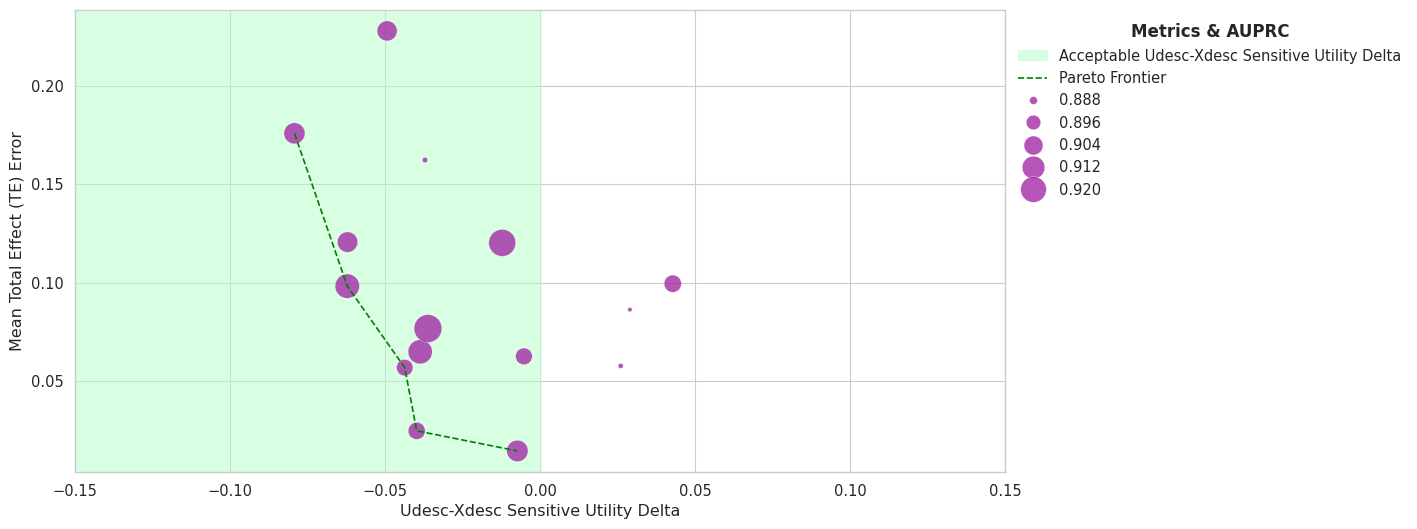

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# OBJECTIVES = maximise AUPRC and minimise sensitive utility delta
plt.axvspan(xmin=-0.15, xmax=0, color="#b5ffc7", label='Acceptable Udesc-Xdesc Sensitive Utility Delta', alpha=0.5)
sns.lineplot(data=pareto_frontier_df, x='delta_desc_auc', y='te_error', color="green", marker='', linestyle="--", label="Pareto Frontier", errorbar=None, ax=ax)
sns.scatterplot(data=grouped_search_results, x='delta_desc_auc', y='te_error', color="#a12aa5", alpha=0.8, size="auprc", sizes=(10, 400), ax=ax)
plt.xlim((-.15, 0.15))
plt.xlabel('Udesc-Xdesc Sensitive Utility Delta')
plt.ylabel('Mean Total Effect (TE) Error')
handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1), edgecolor="white")
leg.set_title("Metrics & AUPRC", prop={'size': 12, 'weight': 'bold'})
plt.show()

# OBJECTIVES = maximise AUPRC and minimise sensitive utility delta
# sns.lineplot(data=pareto_frontier_df, x='delta_desc_auc', y='auprc', color="green", marker='', linestyle="--", label="Pareto Frontier", errorbar=None, ax=ax)
# sns.scatterplot(data=grouped_search_results, x='delta_desc_auc', y='auprc', color="#a12aa5", alpha=0.8, size="te_error", sizes=(10, 400), ax=ax)
# plt.xlim((-.15, 0.15))
# plt.xlabel('Udesc-Xdesc Sensitive Utility Delta')
# plt.ylabel('Average Precision (AUPRC)')
# handles, labels = ax.get_legend_handles_labels()
# leg = ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1), edgecolor="white")
# leg.set_title("Metrics & TE Error", prop={'size': 12, 'weight': 'bold'})
# plt.show()